## Lecture 11

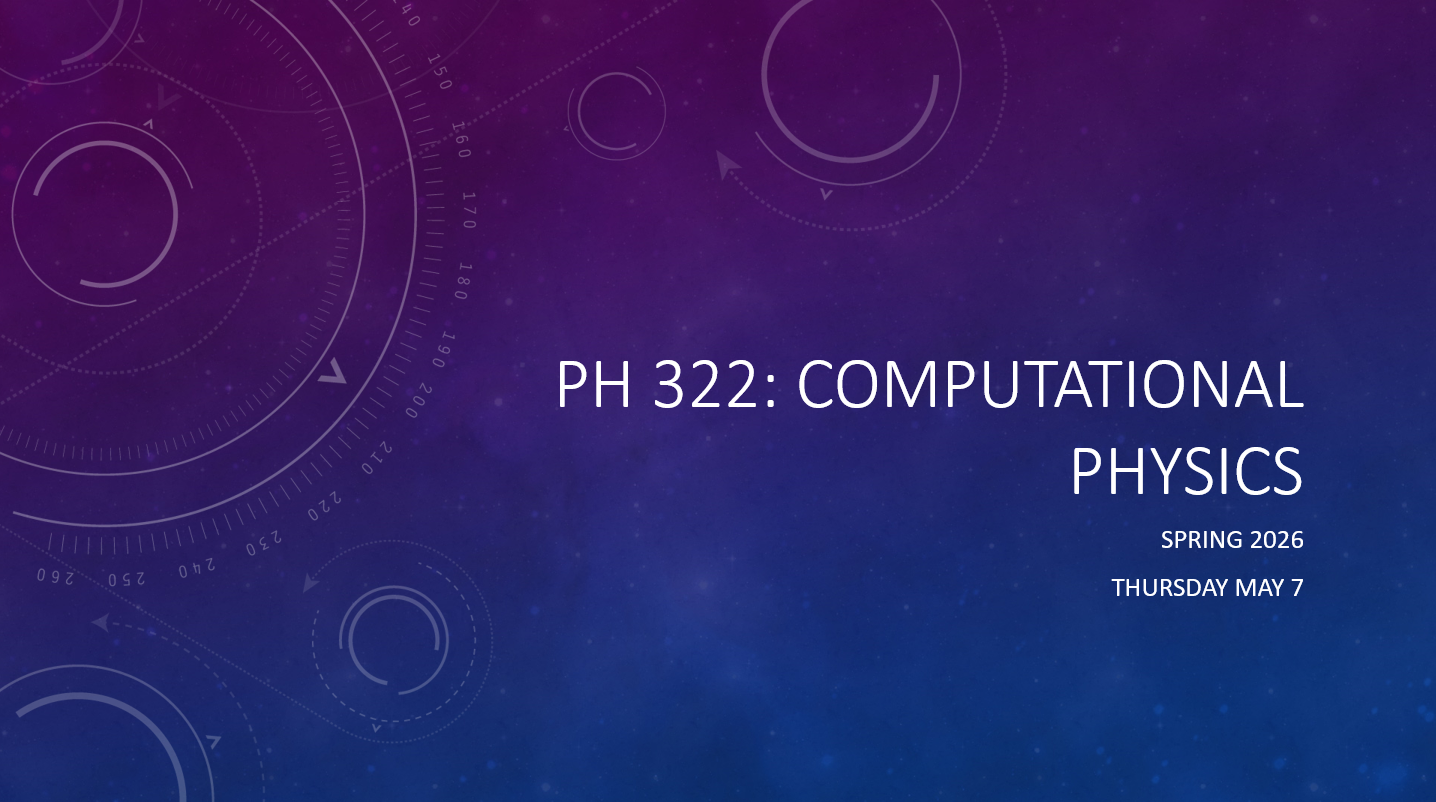

In [17]:
from IPython.display import Image, display
display(Image("G:\\My Drive\\Classes\\Ph322\\2026\\Lectures\\Figures\\header_lecture11.png"))

HW6 is available. Due Tuesday, May 12

I aim to have midterms graded by Tuesday. 

**Last Class**
* Solving non-linear equations
    * The relaxation method
    * Binary search method
    * Newton's method


**Today's Class**
* Solving first-order ordinary differential equations with initial conditions
    * Euler's method
    * 2nd-order Runge-Kutte method
    * 4th-order Runge-Kutte method
* Solving simultaneous 1st order ODEs. 
  



# Ordinary Differential Equations

In this chapter we learn numerical methods for solving ordinary differential equations. We will first tackle first-order ordinary DEs with one variable, then with two or more variables, then finally learn how to solve second-order DEs. 

## First-order ordinary differential equations with one variable

As a refresher, an **ordinary differential equation (ODE)** is a differential equation that contains a function with just one independent variable, unlike a partial differential equation (PDE) that contains functions with more than one independent variable. In physics the independent variable is often time. In general ODEs are easier to solve to the PDEs. 

**First order** means that the equation includes only the **first derivative** of the function. And one variable means the derivative depends on only one dependent variable, in addition to the independent variable. We can such an equation as:

$$
\frac{dx}{dt} = f(x,t).
$$

So for example

$$
\frac{dx}{dt} = x^2 + t.
$$


In this example, the independent variable is time $t$, and the derivative itself depends on the solution to this equation, $x(t)$.  We of course don't know the solution $x$ at all $t$ ahead of time.

If we were to analytically solve this equation, we would find an expression for $x(t)$ valid for all $t$. Numerically however, we specify a time interval over which to solve the equation, and we find values for $x(t)$ over this interval from $t=a$ to $t=b$. We divide this interval up into $N$ number of steps of width $\Delta t = h=(b-a)/N$, similar to what we've done for numerical integration. If we make $h$ small enough, we can approximate a continuous function inside the interval.

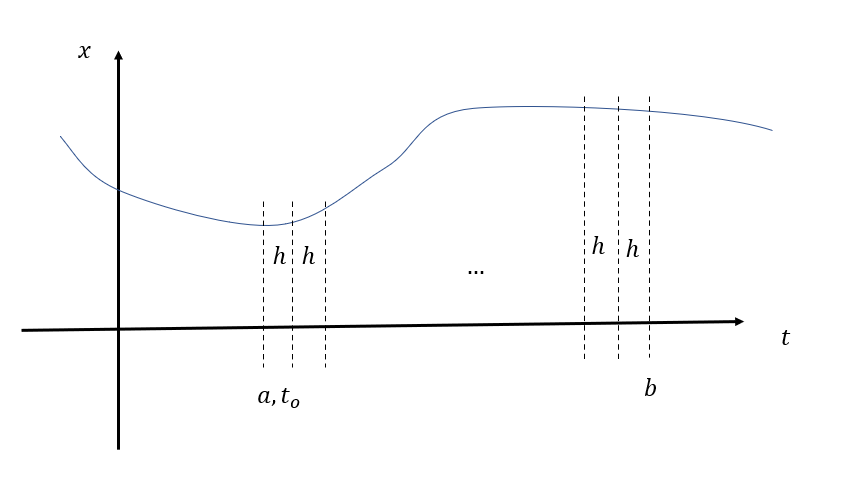

Just like integration there are many numerical methods to solve differential equations. These methods vary by the complexity of the algorithm and accuracy. 

We will start with Euler's method, the simplest algorithm to code. 

### Euler's method

Let's start with the differential equation:

$$
\frac{dx}{dt} = -x^3+\sin{t}
$$


Here $x$ is the dependent variable and $t$ is the independent variable. To solve the equation is to determine the function $x(t)$. Unlike an analytical solution of a differential equation, a numerical solution will not give us the value of $x$ over all $t$, rather we will solve for $x$ over an interval of $t$ from $a$ to $b$. Euler's method is a simple technique we can use to determine this.

First we write our DE in the form of 

$$
\frac{dx}{dt} = f(x,t)
$$

where $f(x,t)=-x^3+\sin{t}$.

Because this is a first order ODE we know we must specify one boundary condition to fix $x(t)$. Usually this will be an initial condition, *i.e.*, the value of $x$ at the beginning of the time interval.

Let's suppose $x(t)$ looks something like this:


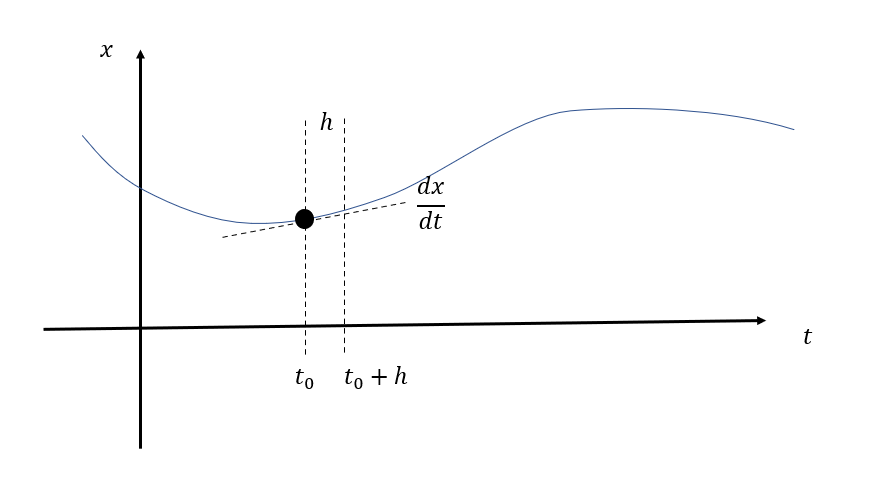

and we know the value of $x(t)$ at some time $t_0$ as shown. 

Euler's method is derived by taking the Taylor series expansion of $x(t)$ about $t_o$:

$$
x(t) = x(t_o) + (\frac{dx}{dt})_{t=t_o}(t-t_o)  + O((t-t_o)^2)
$$

where $O((t-t_o)^2)$ are the terms of order $(t-t_o)^2$ and higher. 

We then evaluate $x(t)$ at a small step forward in time, $t_o+h$:

$$
x(t_o+h) = x(t_o) + \left(\frac{dx}{dt}\right)_{t_o}(t_o+h-t_o) +  O(h^2)
$$

$$
x(t_o+h) = x(t_o) + h\left(\frac{dx}{dt}\right)_{t_o} + O(h^2)
$$

In general $t_o$ could be any time $t$ in our interval.

If we approximate the solution by truncating after the first two terms, 

$$
x(t+h) \sim x(t) + h\frac{dx(t)}{dt} 
$$

where we ignore the higher order terms.





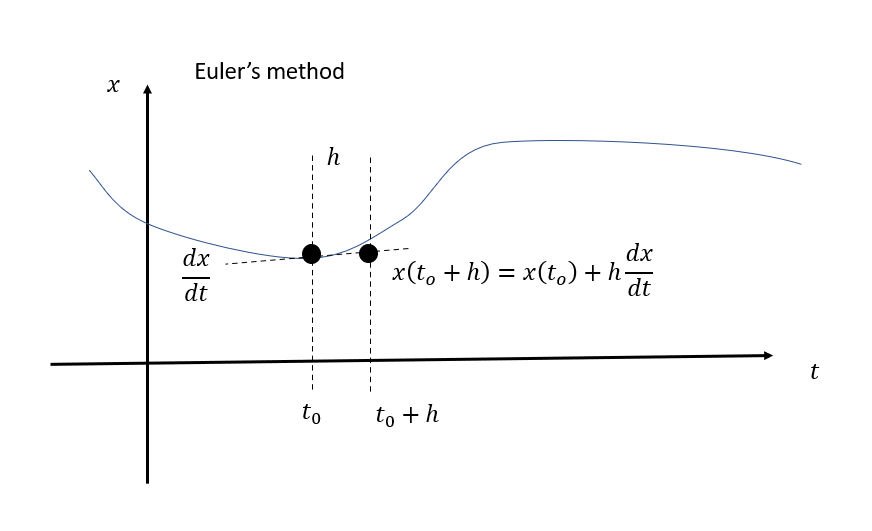

This requires us to find the derivative $\frac{dx}{dt}$ at the current time step $t$.

Since:

$$
\frac{dx}{dt}=f(x,t),
$$


we evaluate the derivative using $f(x,t)$, which means we can write the approximate solution as:

$$
\boxed{x(t+h) = x(t) + hf(x,t) }
$$

where the function $f(x,t)$ is evaluated at $t$, or if this is the first step and we are given the initial condition, at $t_0$. Since we will always know what the solution is at $t$, we can always evaluate the function $f(x,t)$.

This is the numerical solution to the differential equation called **Euler's method**. Given an initial starting value for the solution $x(t)$ we simply step forward calculating the next value by adding the term $hf(x,t)$. We specify the interval (a,b) over which we calculate $x(t)$, and divide the interval into $N$ steps, so $h=(b-a)/N$.

Euler's method is simple to program and efficient because we evaluate the function $f(x,t)$ only once per step. However, compared to other techniques the approximation is fairly large as we will derive below, which means we many steps to drive the error down.  

### Practice: Euler's method

Use Euler's method to solve the differential equation 

$$
\frac{dx}{dt} = -x^3+\sin{t}
$$

over the interval (0,10), given the initial condition $x(t)=0$ at $t=0$. Plot the solution. 

The pseudocode looks like:
1. Define function $f(x,t)$
2. Specify the interval (a,b) over which to evaluate equation, specify the number of time steps N, and provide initial condition.
3. Create containers, *i.e.*, lists or arrays,  to hold the time steps (for plotting) and solution at each step. 
4. Loop through time interval, incrementing by step size $h$.
5. At each step, calculate $x(t+h)$ using Euler's method.

In general choose $N$ so $h<1$. If $h$ is too big, the approximation may be so poor the solution blows up. Try experimenting with $N$. As $N$ increases we get a better approximation to the solution. 

If time permits, write a function to perform Euler's method given a function $f$, time interval, initial condition, and number of time steps. Use your function to calculate the solution using a different number of time steps and plot the solutions on the same graph. 

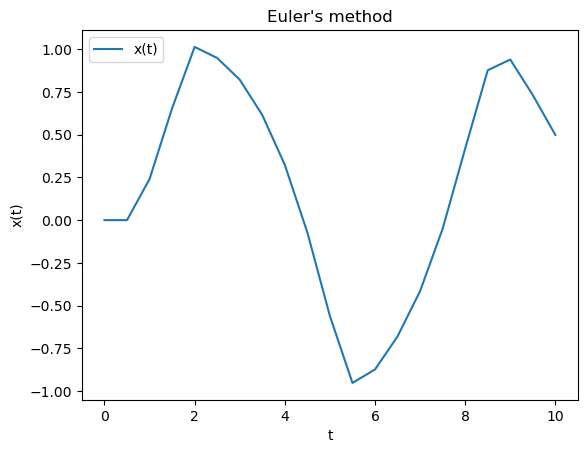

In [ ]:
# User Euler's method solve a first-order ODE 
import numpy as np

def f(x,t):
    return x**3 + np.sin(t)

def euler(f, a, b, N, y0, t0):
    h = (b - a)/N
    time_values = np.arange(a,b+ h, h) 
    approx_values = []

    

    for i, t in enumerate(time_values):

        time_values.append()
        
    

    

The plot shows the solution to the differential equation over the specified interval and with the specified initial condition.

Below I write a function for Euler's method that takes as arguments the function $f$, the time interval, and the number of steps. This makes it easy to compare the solution using different number of time steps.

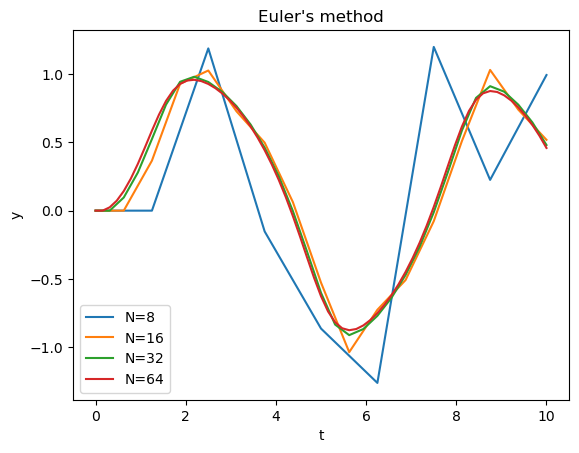

In [16]:
# User Euler's method solve a first-order ODE 



### Approximation error of Euler's method

Being a numerical method, the solution we calculate has some error to it. How can we calculate it?

Well remember, we derived Euler's method from the Taylor series expansion:

$$
x(t+h) = x(t) + \frac{dx(t)}{dt}(h)  + O(h^2)
$$

and ignored the higher order terms. The largest of these terms will typically be the $h^2$ term since $h<1$, so that will determine the error.

From the Taylor series this term is;

$$
\frac{1}{2}h^2\frac{d^2x}{dt^2}
$$

This is the error on every step of the calculation. If we take $N$ steps the total error is;

$$
\sum_{k=0}^{N-1}\frac{1}{2}h^2\left(\frac{d^2x}{dt^2}\right)_{t=t_k}
$$

But since $\frac{dx}{dt}=f(x,t)$:

$$
= \frac{1}{2}h\sum_{k=0}^{N-1}h\left(\frac{df}{dt}\right)_{t=t_k}
$$

where we evaluate the derivative at every step $t_k$.

If $h$ is small then, then we can approximate the  sum as the integral of $\frac{df}{dt}$ over the interval (a,b) as $h\rightarrow dt$:

$$
\sim \frac{1}{2}h\int_{a}^{b}\left(\frac{df}{dt}\right)dt 
$$

$$
= \frac{1}{2}h\left[f(x(b),b)-f(x(a),a)\right]
$$


The main result of interest here is the total approximation error is proportional to $h$, not just $h^2$ of a single step. On one hand this is good because we can reduce the error by increasing the number of steps.  For example, if we double the number of steps, we reduce the error by 2 (assuming $h<1$). Of course, the smaller $h$ is, the more steps it will take to find the solution, increasing the computation time.

This is promising. But can we do better? Yes! Enter the Runge-Kutta method. 


### The 2nd-order Runge-Kutta method

The Runge-Kutta method is a higher order approximation method than Euler's method, meaning that it is more accurate than Euler's method for the same number of steps.  

There is more than one Runge-Kutta (RK) method (actually Euler's method *is* a first-order Runge-Kutta method). 

We will first discuss the 2nd-order RK method which is easier to derive, then finish up with the 4th-order RK method, which is more difficult to derive but more accurate and widely used.

To start, let us first return to Euler's method and look at the figure below.

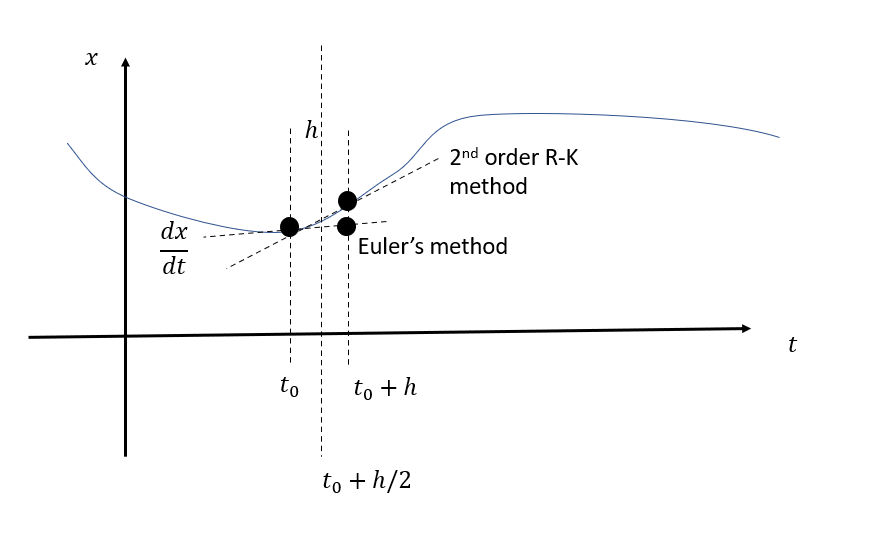

 With Euler's method we start with our initial condition of $x$ at some time $t_o$. Because we have written the differential equation in the form 

$$
\frac{dx}{dt} = f(x,t),
$$

the function $f(x,t)$ evaluated at $t_o$ is the derivative at this point. We then use the derivative to estimate the solution at the next time step $x(t_o+h)$. 

If $x(t)$ is linear between $x(t_o)$ and $x(t_o+h)$, Euler's method provides a good approximation. Of course in general this won't be the case, if the solution varies over the interval $h$,  Euler's methods provides only a poor approximation to the $x(t_o+h)$ as shown. 

From the graph we see it would be better if we could approximate $x(t_o+h)$ using the derivative calculated at the midpoint of the interval. Doing so, would get us closer to the true value.

Well that's the 2nd-order RK method (Actually one version of it. A different version uses the average of the derivative over the time step). We evaluate the derivative at $t_o+\frac{1}{2}h$ instead of at $t_o$. Once we have that derivative we use it to estimate the solution at the next times step,$x(t+h)$,  and repeat the process.

**Using Euler's method within the RK method**

Sounds good. What's the catch?

Well the problem is, in order to calculate the derivative at $t+\frac{1}{2}h$, we need to evaluate the function $f(x,t)$ at  $t+\frac{1}{2}h$, which requires us to know the solution $x(t+\frac{1}{2}h)$, which we don't. We know $x(t)$ because that is either the initial condition or the solution at the current step $t$. But we don't know the value of $x$ at the midpoint of the time step.

So what do we do?

We actually cheat a little and use Euler's method to estimate the solution at the midpoint,  $x(t+\frac{1}{2}h)$. Once we know $x(t+\frac{1}{2}h)$, we evaluate the derivative at the midpoint using $f(x(t+\frac{1}{2}h),t+\frac{1}{2}h)$, then use that derivative to calculate the solution at $t+h$. 

This whole procedure is called the **2nd-order RK method**. Using Euler's method to calculate the value of $x$ at the midpoint, allows us to calculate a more accurate value of $x$ at $t+h$. 

The pseudocode of the 2nd-order RK method looks something like this:

1. Create a function for $f(x,t)$.
2. Define the solution interval (a,b) and specify the initial condition and number of steps N. Calculate the step width $h$.
3. Create containers for x and t values.
4. Populate x and t with initial values.
5. Loop over solution interval:
   * Calculate the derivative at current time $t$ by evaluating the function $f(x,t)$.
   * Use Euler's method to estimate $x(t+\frac{1}{2}h)$ with this derivative, i.e. $x(t+\frac{1}{2}h) = x(t) + \frac{h}{2}f(x,t)$ 
   * Once we know $x(t+\frac{1}{2}h)$, calculate the derivative at the midpoint with $f(x(t+\frac{1}{2}h),t+\frac{1}{2}h)$
   * Finally calculate $x(t+h) = x(t) + hf(x(t+\frac{1}{2}h),t+\frac{1}{2}h)$



If we substitute the second bulleted step into the last, we can calculate $x(t+h)$ in one step:

$$
x(t+h) = x(t) + hf(x(t) + \frac{h}{2}f(x,t),t+\frac{1}{2}h)
$$

Notice we evaluate the function only at the current time step.

You can see this is straightforward to code. Just loop over each step in your interval, and calculate successive steps of $x$ with the above calculations.

One final note. You may wonder if the use of Euler's method increases the approximation error on our estimate of the solution? It turns it introduces an approximation also on the order of $h^3$, so the overall method is still accurate to the second order of $h$ (see proof of this on p. 336 in text). 

 

### Practice  The second-order Runge-Kutta method

Solve the differential equation using the 2nd order Runge-Kutta method:

$$
\frac{df}{dx} = -x^3+sin(t)
$$

If time permits, copy your Euler's method code from above, and use both to calculate the solution using the same number of steps. Plot both solutions on the same graph. 

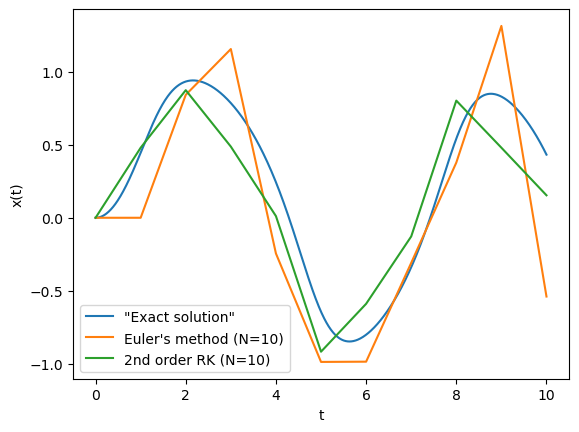

In [10]:
# Use 2nd order RK method solve a first-order ODE 






In the above block of code we calculate the solution using both Euler's method and the 2nd-order RK method to compare.

For small values of N, around 15 or so, we see clearly that the 2nd-order RK is converging on the solution sooner than Euler's method. We need roughly 100 step before Euler's method gives nearly the same solution as RK. 



**Approximation error to 2nd-order RK method**

The approximation error introduced by using the 2nd-order RK method can be using a Taylor series' expansion.  

We first expand $x(t)$ about the midpoint time $t+\frac{1}{2}h$:


$$
x(t) = x(t+\frac{1}{2}h) + \left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}(t-(t+\frac{1}{2}h)) + \frac{1}{2}\left(\frac{d^2x}{dt^2}\right)_{t+\frac{1}{2}h}(t-(t+\frac{1}{2}h))^2+O(h^3)
$$

We now evaluate this function first at $t+h$, which is 

$$
x(t+h) = x(t+\frac{1}{2}h) + \frac{h}{2}\left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h} + \frac{h^2}{8}\left(\frac{d^2x}{dt^2}\right)_{t+\frac{1}{2}h}+O(h^3)
$$

then again at $t$:

$$
x(t) = x(t+\frac{1}{2}h) - \frac{h}{2}\left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h} + \frac{h^2}{8}\left(\frac{d^2x}{dt^2}\right)_{t+\frac{1}{2}h}+O(h^3)
$$


Now subtract these two equations:

$$
x(t+h) - x(t) = h\left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}+O(h^3)
$$

or 

$$
x(t+h)  = x(t) + h\left(\frac{dx}{dt}\right)_{t+\frac{1}{2}h}+O(h^3)
$$

Because $\frac{dx}{dt}=f(x,t)$, we can write this as:

$$
\boxed{x(t+h)  = x(t) + hf(x(t+\frac{1}{2}h),t+\frac{1}{2}h)+O(h^3)}
$$

This now is just the estimate of $x(t+h)$ using the value of the derivative at  $t+\frac{1}{2}h$, i.e. this is the 2nd-order RK method.

And notice the first term we omit from the method is $O(h^3)$, that is the term that is proportional to $h^3$. Meaning that when we use 2nd-order RK to approximate $x(t+h)$, the approximation is accurate to $h^2$, thus the name *2nd-order* RK.

Keep in mind however, this is the error on a single step. The errors on each step add up across the interval. Just like we found in Euler's method, the total is about 1 order of $h$ larger than for a single step. So the total approximation error is proportional to $h^2$ not $h^3$. 

The 2nd-order RK method looks pretty good and is to easy code. Can we do better? Yes, the 4th order RK method!

### 4th order Runge-Kutta method

Now that we have proceeded down this fruitful path of taking the derivatives at the midpoints of intervals to approximate the $x(t)$ at the end of the step, there is no need to stop. We can divide the interval $h$ into 4 sub-intervals and calculate the derivatives at the midpoints of these. 

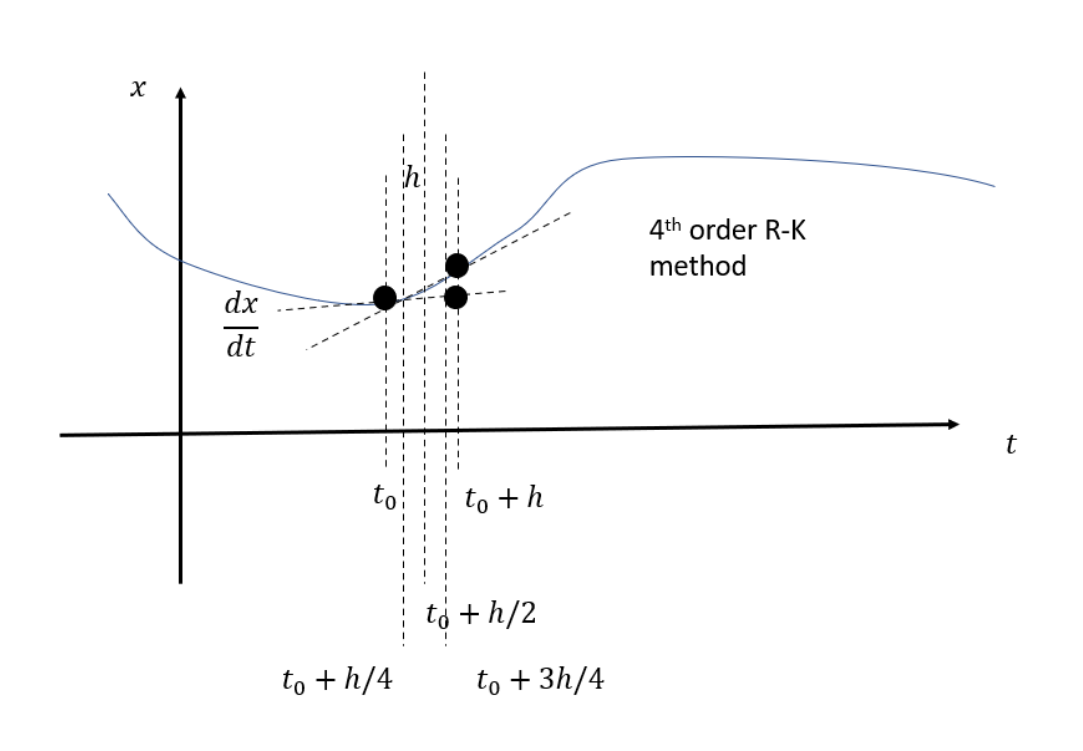





We again expand $x(t)$ about the midpoints and calculate linear combinations of the Taylor series.

As we continue to do this, the equations we need to code increase in both number and complexity. So there is a sweet spot between these trade-offs that is usually taken to be the **4th-order Runge-Kutta method**, which as the name suggests is accurate to the 4th order of $h$. 

Most texts don't show the long derivation of this, but the end result is this straightforward set of equations to code:

$
\begin{array}{l}
k_1  &=  hf(x,t) \\
k_2 &=  hf(x+\frac{1}{2}k_1, t+\frac{1}{2}h) \\
k_3 &=  hf(x+\frac{1}{2}k_2, t+\frac{1}{2}h) \\
k_4 &=  hf(x+k_3, t+h) \\
x(t+h) &= x(t) + \frac{1}{6}(k_1+2k_2+2k_3+k_4)
\end{array}
$


This really isn't too bad. You can pretty much copy and paste this into your program with only a small amount of editing.

I'll add the code to my program above so we can compare all three methods:

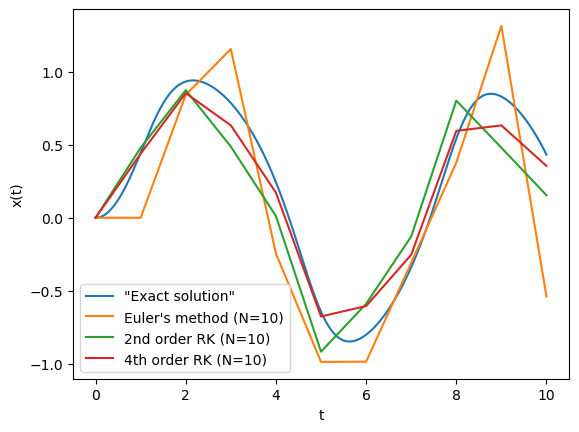

In [16]:
# Use 4th order RK method solve a first-order ODE 



We run the program with N=10, 20, and 50 slices. We see even at only 10 slices the 4th-order RK is beginning to get the curvature of the solution correct. 

The 4th order RK method is one of the most commonly used numerical methods to solve ODEs because it is pretty easy to code and very accurate. 

### Systems of differential equations with more than one dependent variable

Next we will look at systems of simultaneous first-order ODEs.These systems have two or more dependent variables and the derivatives depend on both dependent variables. For example, the Lotka–Volterra equations, also known as the predator-prey equations have two dependent variables, $x,y$:

$$
\frac{dx}{dt}=\alpha x - \beta xy,
$$

$$
\frac{dy}{dt}=\gamma xy - \delta y.
$$

The dependent variables $x$ and $y$ are proportional to the size of the populations of
two species, traditionally called “rabbits” (the prey) and “foxes” (the predators). 

In the model the rabbits reproduce at a rate proportional to their population $x$,
but are eaten by the foxes at a rate proportional to both their own population and the
population of foxes $y$.

At the same time the foxes reproduce at a rate proportional to the rate at which they eat rabbits—because they need food to grow and reproduce—but also die of old age at a rate proportional to their own population.

In general, we can write a system of ODEs as: 

$$
\frac{dx}{dt} = f_x(x,y,t)
$$

$$
\frac{dy}{dt} = f_y(x,y,t)
$$

where $f_x$ and $f_y$ indicates two different functions, one for the derivative of $x$ and the second one for $y$. 

Notice now each derivative is dependent on two variables, $x$ and $y$, whereas before the derivatives we worked with were dependent on only one variable. 

For coding purposes, it is beneficial to write this set of equations in compact form using vector notation. 

For instance, define vector $\boldsymbol{r}$ as:

$$
\boldsymbol{r}=(x(t),y(t)),
$$ 

and vector $\boldsymbol{f}$:

$$
\boldsymbol{f}(\boldsymbol{r},t) = (f_x(x,y,t),f_y(x,y,t)).
$$ 

We can then write the two differential equations above in vector notation as:

$$
\frac{d\boldsymbol{r}}{dt} = \boldsymbol{f}(\boldsymbol{r},t).
$$


In general we could have any number of dependent variables, with a corresponding number of differential equations.

We can derive Euler's method and the RK methods by Taylor expanding around $\boldsymbol{r}$ for the vector form of these equations. 

For example if we Taylor expand around $\boldsymbol{r}$ at $t$, and evaluate at $t+h$ we get;

$$
\boldsymbol{r}(t+h) = \boldsymbol{r}(t) + h\frac{d\boldsymbol{r}}{dt}+O(h^2) 
$$

Replacing the derivative with the vector of functions $\boldsymbol{f}(\boldsymbol{r},t)$, we get:

$$
\boldsymbol{r}(t+h) = \boldsymbol{r}(t) + h\boldsymbol{f}(\boldsymbol{r},t) +O(h^2)
$$

which is just Euler's method for the vector $\boldsymbol{r}$.

So this is now a vector equation. When we code this in Python, the bold-faced variables are no longer scalar variables, but are ```numpy``` arrays.

We can define a function ```f(r)``` that takes as input the array ```r``` that holds the solutions of both the $x$ and $y$ variables. We then can have our function return $f_x$ and $f_y$ to the calling routine. Otherwise, everything else is the same. 



**4th-order RK for two variables**

Likewise, we can adapt the Runge-Kunge methods for use in solving systems of ODEs. Here are the vector equations for the 4th-order RK method:

$
\begin{array}{l}
\boldsymbol{k_1}  &=  h\boldsymbol{f}(\boldsymbol{r},t) \\
\boldsymbol{k_2} &=  h\boldsymbol{f}(\boldsymbol{r}+\frac{1}{2}\boldsymbol{k_1}, t+\frac{1}{2}h) \\
\boldsymbol{k_3} &=  h\boldsymbol{f}(\boldsymbol{r}+\frac{1}{2}\boldsymbol{k_2}, t+\frac{1}{2}h) \\
\boldsymbol{k_4} &=  h\boldsymbol{f}(\boldsymbol{r}+\boldsymbol{k_3}, t+h) \\
\boldsymbol{r}(t+h) &= \boldsymbol{r}(t) + \frac{1}{6}(\boldsymbol{k_1}+2\boldsymbol{k_2}+2\boldsymbol{k_3}+\boldsymbol{k_4})
\end{array}
$

Now each $\mathbf{k}$ is a ```numpy``` array and stores a number of values equal to the number of variables. Other than that, the coding is just as easy as coding for a single variable.

Note you don't even need to initially define the $\mathbf{k}$'s to be 1D arrays of size-2 since Python is smart enough to make them these upon their initial usage since the function $f$ will return a size-2 array. 



### Practice Exercise: Lotka-Volterra equations


Let's try this out by solving the Lotka–Volterra equations:

$$
\frac{dx}{dt}=\alpha x - \beta xy,
$$

$$
\frac{dy}{dt}=\gamma xy - \delta y.
$$



Solve the two differential equations using $\alpha=1$, $\beta=\gamma=0.5$, $\delta = 2$ starting from initial condition $x=y=2$. 

In this case, our $\boldsymbol{r}$ vector is (x,y) and the $\boldsymbol{f}$ vector is $\left(\alpha x - \beta xy ,\gamma xy - \delta y \right).$ You can use ```numpy``` arrays to store the vectors. You can create a Python function for $\boldsymbol{f}$ that takes $\boldsymbol{r}$ as an argument and calculates both $f_x$ and $f_y$, which are both returned to the calling statement. 

Otherwise you can pretty much copy your Euler method code from above, only edit the containers you use to store the times and solutions. 

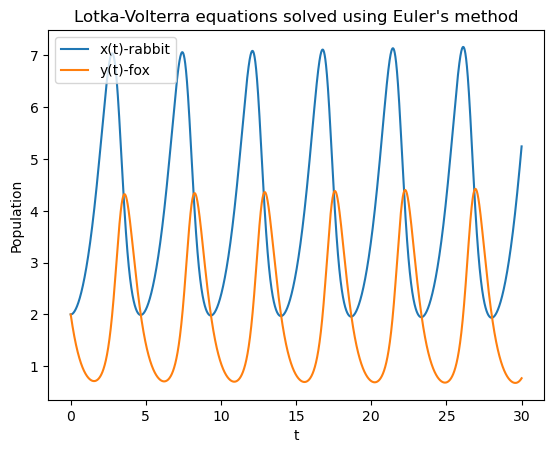

In [22]:
# Euler's method for a system of first-order ODEs
# Lotka-Volterra equations from Exercise 8.2





I created a 1D array of size-2 called $r$ to store the current values of both $x$ and $y$. This way I just need one equation in my Euler's method loop. I also create a 2xN array to store the solutions, each variable will be stored in one of the array rows. I suppose we could also store the solutions in a list, but since we are working with a 2D dataset I find it easier to work with arrays.

You can see the plot shows both $x(t)$ and $y(t)$, both solutions stored in the $r_{euler}$ array. Other than one additional line of code to store both solutions in my loop, the length of the main loop is the same, despite solving two equations. Of course we can generalize this to any number of variables.

You might want to look at how the rabbit and fox populations change with time and see if the behavior of their populations make sense, given the assumptions in the predator-prey model.

One final thing to note is the large number of time steps required in order to keep the solution stable. This as we noted above is a weakness of Euler's method. The peak populations of both species should remain constant with time. Explore what values of $N$ are required to ensure this condition. 